# XgenePy Multi-Condition Example

This notebook mirrors the `XgeneR` multi-condition vignette using the full Ballinger dataset.

The repository also includes `cold_ballinger_counts.csv` and a derived `cold_ballinger_metadata.csv` in `data/` if you want to work with the cold-only subset.

In [1]:
from pathlib import Path
import sys

import pandas as pd

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if (repo_root / 'src').exists() and str(repo_root / 'src') not in sys.path:
    sys.path.insert(0, str(repo_root / 'src'))

from xgenepy import FitObject, fit_edgepython, get_assignments_and_plot, plot_pval_histograms, plot_regulatory_histogram

Load the full Ballinger counts and metadata used in the multi-condition vignette.

In [2]:
data_dir = repo_root / 'data'
counts = pd.read_csv(data_dir / 'ballinger_counts.csv', index_col=0)
metadata = pd.read_csv(data_dir / 'ballinger_metadata.csv', index_col=0)
if 'Sample' in metadata.columns:
    metadata.index = metadata['Sample'].astype(str)

counts.shape, metadata.shape

((5706, 96), (96, 5))

Create a multi-condition fit object testing `Tissue` and `Temperature`.

In [3]:
fit_obj = FitObject(
    counts=counts,
    metadata=metadata,
    trans_model='log_additive',
    fields_to_test=['Tissue', 'Temperature']
)
fit_obj = fit_edgepython(fit_obj)

fit_obj.raw_pvals.filter(regex='Liver\\*Warm').head()

/home/maria/miniconda3/envs/env1/lib/python3.12/site-packages/edgepython/dispersion_lowlevel.py:509: RuntimeWarning: invalid value encountered in subtract
  return (np.sum(gammaln(y + r[:, None]), axis=1) +


,Liver*Warm null: no cis,Liver*Warm null: no trans
ENSMUSG00000000056,0.776257,0.745105
ENSMUSG00000000058,0.854071,0.854040
ENSMUSG00000000078,0.415431,0.359485
ENSMUSG00000000088,1.000000,0.934421
ENSMUSG00000000120,0.239425,0.286799


Plot the cis and trans p-value/FDR histograms for the `Liver*Warm` condition.

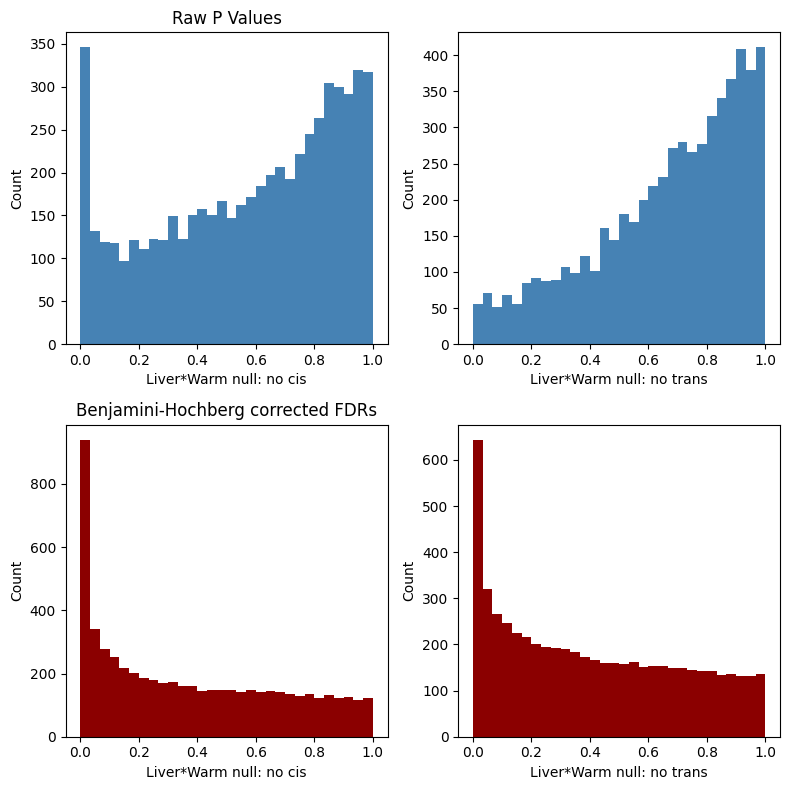

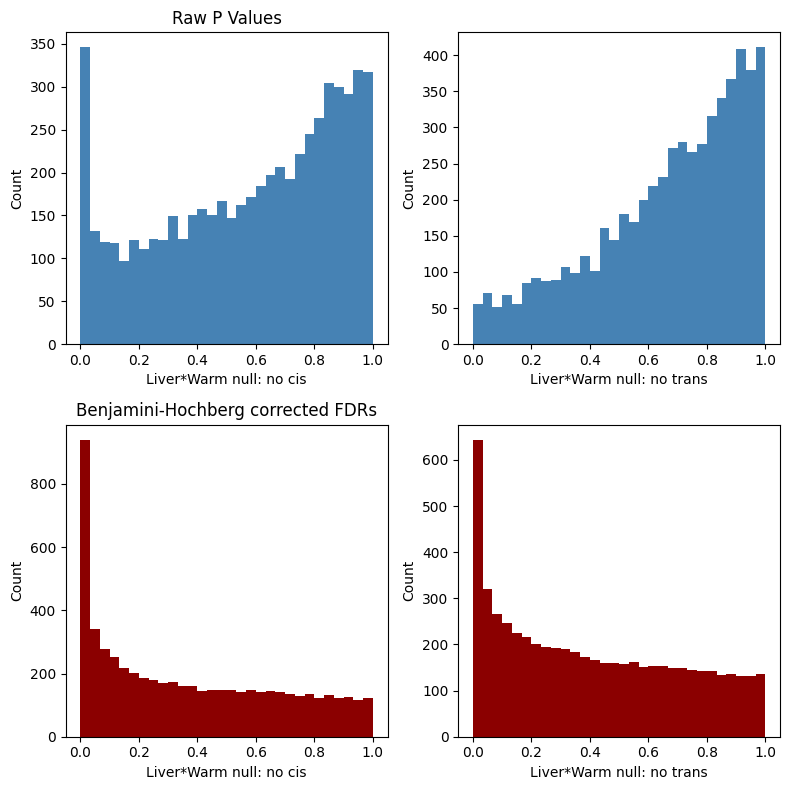

In [4]:
pval_fig = plot_pval_histograms(fit_obj, combo='Liver*Warm')
pval_fig

Get assignments and diagnostic plots for the same condition.

,gene,reg_assignment,cis_prop
ENSMUSG00000000056,ENSMUSG00000000056,conserved,0.369119
ENSMUSG00000000058,ENSMUSG00000000058,conserved,1.712727
ENSMUSG00000000078,ENSMUSG00000000078,conserved,1.607461
ENSMUSG00000000088,ENSMUSG00000000088,conserved,0.002258
ENSMUSG00000000120,ENSMUSG00000000120,cisxtrans,1.635445


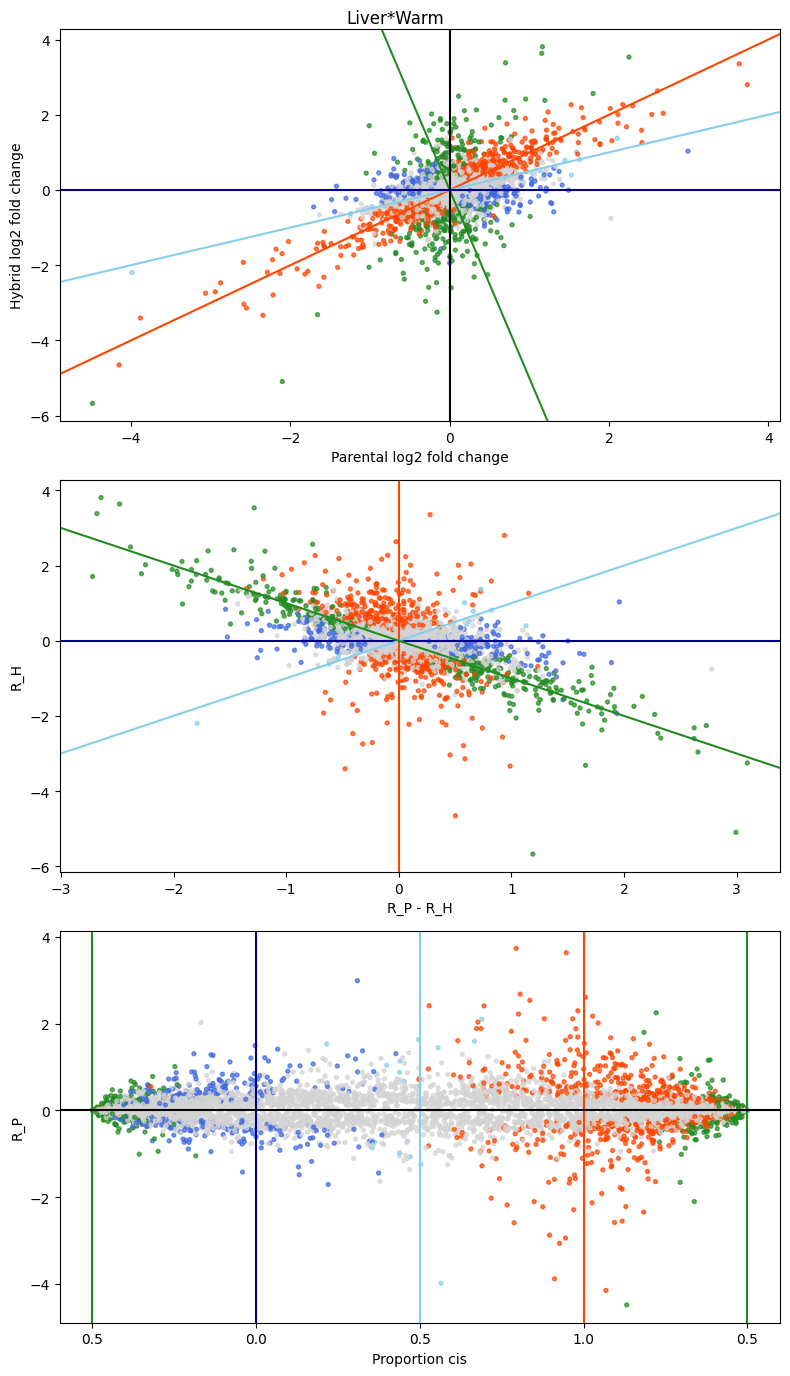

In [5]:
results = get_assignments_and_plot(fit_obj, combo='Liver*Warm', make_plot=True, alpha=0.05)
results.dataframe[['gene', 'reg_assignment', 'cis_prop']].head()

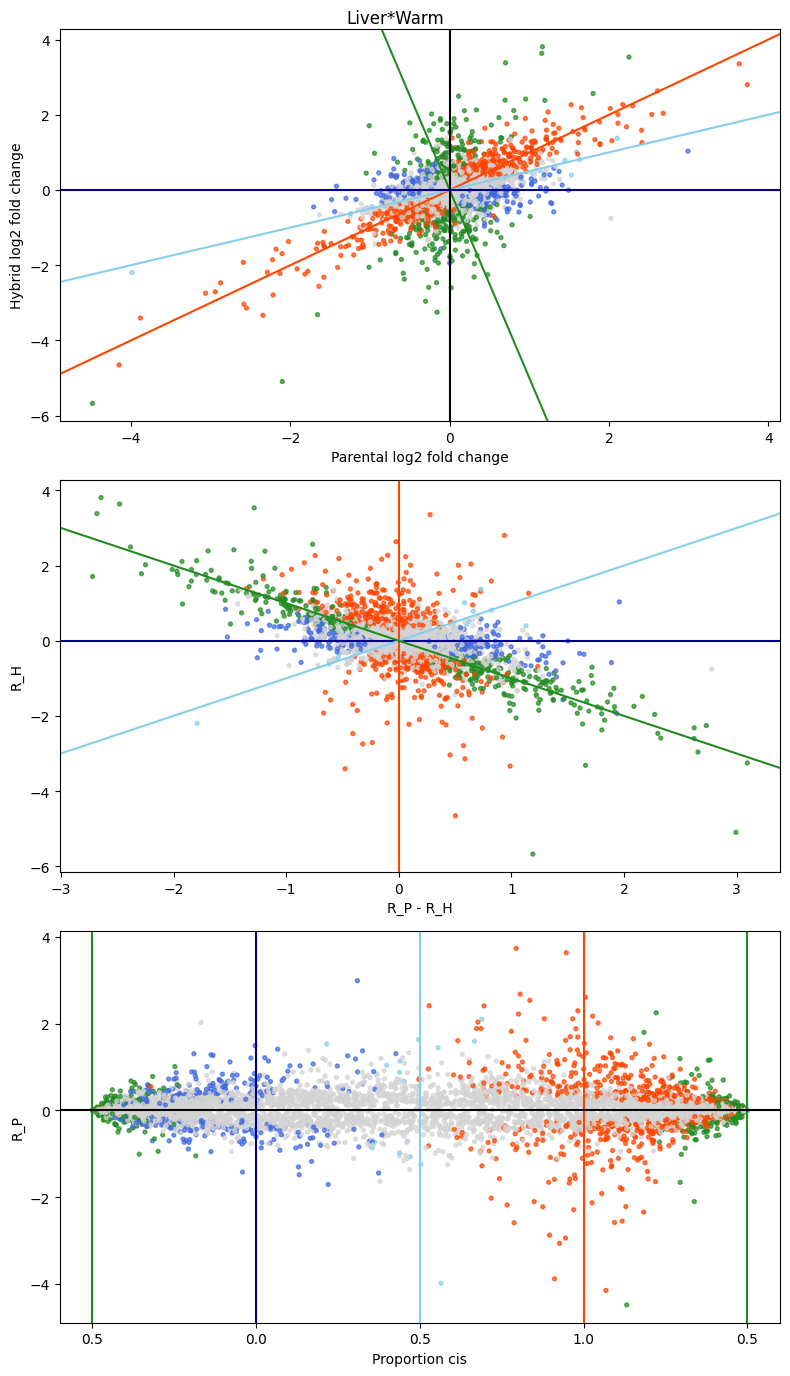

In [6]:
results.figure

Summarize the assignment counts for `Liver*Warm`.

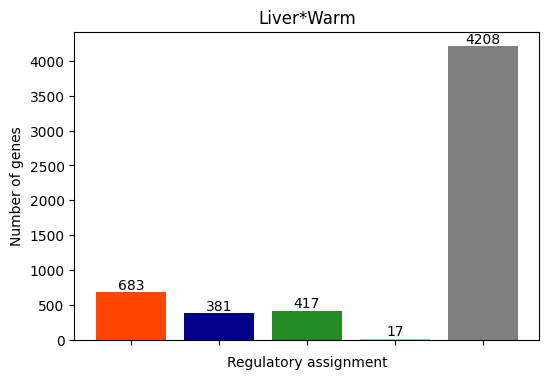

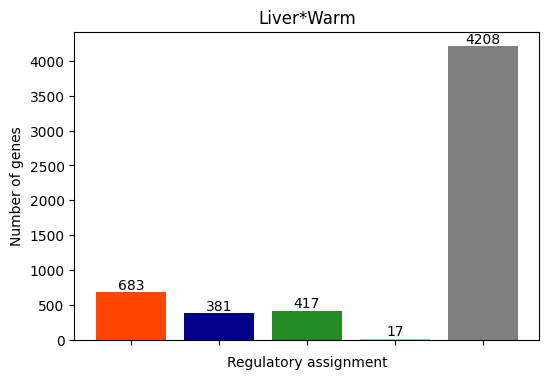

In [7]:
reg_fig = plot_regulatory_histogram(results.dataframe, title='Liver*Warm')
reg_fig